¡Hola!

Mi nombre es Marcos Torres y tengo el gusto de revisar tu código el día de hoy.

Cuando vea algo notable o algún asunto en el notebook, te dejaré un comentario o un hint. Se que encontraras la mejor respuesta para resolver todos los comentarios, de no ser así, no te preocupes en futuras iteraciones dejaré comentarios y pistas más específicos.

Este proceso es muy parecido al que se recibe de un gerente o de un Senior Data Scientist en un trabajo real, por lo que te estarás preparando para la experiencia en la vida real.

Encontrarás comentarios en verde, amarillo o rojo como los siguientes:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen trabajo. ¡Lo hiciste muy bien!
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Nota. Se puede mejorar.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesitas corregirlo. Este bloque indica que se requiere una correción. El trabajo no se acepta si tiene estos bloques.
</div>

Puedes responder a mis comentarios usando estos bloques:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, solo recuerda eliminar los comentarios entre corchetes cuando termines el proyecto.
</div>

## Inicialización

In [194]:
from scipy import stats as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Cargar todas las librerías



## Cargar datos

In [195]:
megaline_calls= pd.read_csv('/datasets/megaline_calls.csv')
megaline_internet=pd.read_csv('/datasets/megaline_internet.csv')
megaline_messages=pd.read_csv('/datasets/megaline_messages.csv')
megaline_plans=pd.read_csv('/datasets/megaline_plans.csv')
megaline_users=pd.read_csv('/datasets/megaline_users.csv')
# Carga los archivos de datos en diferentes DataFrames



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Muy bien, usaste una celda independiente para importar las librerías y otra para leer los datos.
</div>

In [196]:
megaline_calls.info()
megaline_internet.info()
megaline_messages.info()
megaline_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dty

In [197]:
print(megaline_calls['call_date'].unique)

<bound method Series.unique of 0         2018-12-27
1         2018-12-27
2         2018-12-27
3         2018-12-28
4         2018-12-30
             ...    
137730    2018-11-21
137731    2018-10-20
137732    2018-09-21
137733    2018-10-10
137734    2018-12-29
Name: call_date, Length: 137735, dtype: object>


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen uso de las librerías de pandas para explorar los datos.
</div>

## Preparar los datos

## Tarifas

In [198]:
megaline_plans.info()
megaline_plans.duplicated().sum()# Imprime la información general/resumida sobre el DataFrame de las tarifas



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


0

In [199]:
megaline_plans.sample(2)# Imprime una muestra de los datos para las tarifas



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Corregir datos

In [200]:
print(megaline_plans.isnull().sum())
print('considero que para el dataframe megaline_plans no es necesario hacer correcciones')

messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64
considero que para el dataframe megaline_plans no es necesario hacer correcciones


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, se exploró correctamente esta tabla.
</div>

## Enriquecer los datos

## Usuarios/as

In [201]:
megaline_users.info()
print('user_id Duplicados:', megaline_users['user_id'].duplicated().sum())
print('Duplicados:',megaline_users.duplicated().sum())
print(megaline_users.isnull().sum())# Imprime la información general/resumida sobre el DataFrame de usuarios



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
user_id Duplicados: 0
Duplicados: 0
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


In [202]:
megaline_users.sample(20)# Imprime una muestra de datos para usuarios



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
53,1053,Piper,Espinoza,27,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-07-30,surf,NaN
27,1027,Georgeanna,Cardenas,38,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-26,surf,NaN
449,1449,Boyd,Kelley,39,"Seattle-Tacoma-Bellevue, WA MSA",2018-10-04,surf,NaN
392,1392,Gale,Mcfadden,34,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-24,surf,NaN
139,1139,Thomas,Lawson,66,"New Orleans-Metairie, LA MSA",2018-11-18,surf,NaN
215,1215,Adelle,Knapp,70,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-07-01,surf,NaN
35,1035,Jeff,Cummings,67,"Charlotte-Concord-Gastonia, NC-SC MSA",2018-12-08,surf,NaN
491,1491,Terina,Jensen,22,"Grand Rapids-Kentwood, MI MSA",2018-04-27,surf,2018-09-18
480,1480,Jasper,Buchanan,46,"St. Louis, MO-IL MSA",2018-12-13,surf,NaN
37,1037,Reena,Velazquez,20,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-11,ultimate,NaN




En el Dataframe megaline_users considero que los cambios necesarios son a las fechas ya que no estan el el dtype adecuado el cual debe de ser datetime64 y en churndate hay 466 datos ausentes ya que esos clientes no han cancelado su plan pero aun asi creo que es mejor rellenarlos con algo en el dataframe para poder trabajar mejor. 

### Corregir los datos

In [203]:
megaline_users['reg_date']= pd.to_datetime(megaline_users['reg_date'])
megaline_users['churn_date']= pd.to_datetime(megaline_users['churn_date'])
megaline_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Muy bien, se manejaron correctamente las columnas con fechas.
</div>

### Enriquecer los datos

## Llamadas

In [204]:
megaline_calls.info()
print('id duplicados:', megaline_calls['id'].duplicated().sum())
print('Duplicados:',megaline_calls.duplicated().sum())
print(megaline_calls.isnull().sum())# Imprime la información general/resumida sobre el DataFrame de las llamadas



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
id duplicados: 0
Duplicados: 0
id           0
user_id      0
call_date    0
duration     0
dtype: int64


In [205]:
megaline_calls.sample(10)# Imprime una muestra de datos para las llamadas



,id,user_id,call_date,duration
64089,1232_375,1232,2018-06-17,23.49
46740,1170_421,1170,2018-10-09,16.17
96473,1343_159,1343,2018-08-30,0.00
104800,1368_522,1368,2018-06-15,0.00
110214,1389_257,1389,2018-06-27,21.98
122720,1434_3,1434,2018-11-21,10.77
121929,1430_558,1430,2018-12-29,14.70
80674,1291_274,1291,2018-05-14,11.20
8785,1041_220,1041,2018-12-24,3.75
122948,1434_258,1434,2018-05-16,11.77


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, se exploró correctamente esta tabla.
</div>



En el dataframe megaline_calls nuevamente encontramos el error de las fechas de call_date que debe estar en datetime64.
En este dataframe no encontramos duplicados ni datos ausentes.

### Corregir los datos

In [206]:
megaline_calls['call_date']= pd.to_datetime(megaline_calls['call_date'])
megaline_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enriquecer los datos

## Mensajes

In [207]:
megaline_messages.info()
print('id duplicados:', megaline_messages['id'].duplicated().sum())
print('Duplicados:',megaline_messages.duplicated().sum())
print(megaline_messages.isnull().sum())# Imprime la información general/resumida sobre el DataFrame de los mensajes



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
id duplicados: 0
Duplicados: 0
id              0
user_id         0
message_date    0
dtype: int64


In [208]:
megaline_messages.sample(10)# Imprime una muestra de datos para los mensajes



,id,user_id,message_date
15341,1101_398,1101,2018-12-30
15273,1101_330,1101,2018-12-19
37255,1247_419,1247,2018-09-18
21841,1132_1346,1132,2018-12-29
36603,1244_35,1244,2018-11-30
28700,1174_490,1174,2018-07-23
27099,1167_56,1167,2018-08-27
46870,1320_114,1320,2018-07-21
56132,1355_152,1355,2018-10-14
36968,1247_132,1247,2018-11-21




Nuevamente en el dataframe megaline_messages encontramos que message_date debe de estar en dtype datetime64.
No se encontraron datos ausentes ni duplicados.

### Corregir los datos

In [209]:
megaline_messages['message_date']= pd.to_datetime(megaline_messages['message_date'])
megaline_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen trabajo. La tabla de mensajes se trato correctamente.
</div>

## Internet

In [210]:
megaline_internet.info()
print('id duplicados:', megaline_internet['id'].duplicated().sum())
print('Duplicados:',megaline_internet.duplicated().sum())
print(megaline_internet.isnull().sum())# Imprime la información general/resumida sobre el DataFrame de internet



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
id duplicados: 0
Duplicados: 0
id              0
user_id         0
session_date    0
mb_used         0
dtype: int64


In [211]:
megaline_internet.head(10)# Imprime una muestra de datos para el tráfico de internet



,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
5,1001_0,1001,2018-08-24,284.68
6,1001_3,1001,2018-12-09,656.04
7,1001_4,1001,2018-11-04,16.97
8,1001_10,1001,2018-11-27,135.18
9,1001_15,1001,2018-12-13,761.92




En megaline_internet econtramos que el dtype de session_date debe estar en datetime64.
No se encontraron duplicados ni datos ausentes.

### Corregir los datos

In [212]:
megaline_internet['session_date']= pd.to_datetime(megaline_internet['session_date'])
megaline_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen manejo de la tabla de internet.
</div>

## Estudiar las condiciones de las tarifas

In [213]:
megaline_plans.head()# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario



In [214]:
megaline_calls['month']= megaline_calls['call_date'].dt.month 

In [215]:

user_calls= megaline_calls.groupby(['user_id', 'month']).agg({'id':'count'})
user_calls=user_calls.rename(columns={'id':'calls_per_month'})
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
print(user_calls.head(20))


               calls_per_month
user_id month                 
1000    12                  16
1001    8                   27
        9                   49
        10                  65
        11                  64
        12                  56
1002    10                  11
        11                  55
        12                  47
1003    12                 149
1004    5                   21
        6                   44
        7                   49
        8                   49
        9                   42
        10                  61
        11                  54
        12                  50
1005    12                  59
1006    11                   2


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen uso del group by para agrupar los datos por usuario y mes.
</div>

In [216]:
user_minutes= megaline_calls.groupby(['user_id', 'month']).agg({'duration':'sum'})
user_minutes=user_minutes.rename(columns={'duration':'minutes_per_month'})# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
print(user_minutes.head(50))


               minutes_per_month
user_id month                   
1000    12                116.83
1001    8                 171.14
        9                 297.69
        10                374.11
        11                404.59
        12                392.93
1002    10                 54.13
        11                359.76
        12                363.24
1003    12               1041.00
1004    5                 181.58
        6                 261.32
        7                 358.45
        8                 334.86
        9                 284.60
        10                341.63
        11                452.98
        12                403.53
1005    12                470.22
1006    11                  9.32
        12                 54.79
1007    8                 427.95
        9                 375.83
        10                610.65
        11                490.29
        12                579.43
1008    10                450.21
        11                422.81
        12

In [217]:
megaline_messages['month']= megaline_messages['message_date'].dt.month 
user_messages=megaline_messages.groupby(['user_id', 'month']).agg({'id':'count'})
user_messages= user_messages.rename(columns={'id':'messages_per_month'})
print(user_messages.head(40))# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.



               messages_per_month
user_id month                    
1000    12                     11
1001    8                      30
        9                      44
        10                     53
        11                     36
        12                     44
1002    10                     15
        11                     32
        12                     41
1003    12                     50
1004    5                       7
        6                      18
        7                      26
        8                      25
        9                      21
        10                     24
        11                     25
        12                     31
1005    12                     11
1006    11                     15
        12                    139
1007    8                      51
        9                      47
        10                     59
        11                     48
        12                     50
1008    10                     21
        11    

In [218]:
megaline_internet['month']= megaline_internet['session_date'].dt.month 
user_internet= megaline_internet.groupby(['user_id', 'month']).agg({'mb_used':'sum'})
print(user_internet.head(30))# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.



                mb_used
user_id month          
1000    12      1901.47
1001    8       6919.15
        9      13314.82
        10     22330.49
        11     18504.30
        12     19369.18
1002    10      6552.01
        11     19345.08
        12     14396.24
1003    12     27044.14
1004    5       6547.21
        6      20672.82
        7      24516.62
        8      27981.74
        9      18852.72
        10     14541.63
        11     21850.78
        12     21389.29
1005    12     17140.17
1006    11      2068.37
        12     32118.82
1007    8      24439.88
        9      28123.95
        10     37885.63
        11     24334.00
        12     29069.28
1008    10     17106.99
        11     23676.72
        12     14689.33
1009    5      20389.40


In [219]:
monthly_data= pd.concat([user_calls, user_internet, user_minutes, user_messages], axis='columns').reset_index()
monthly_data.head(50)# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month



,user_id,month,calls_per_month,mb_used,minutes_per_month,messages_per_month
0,1000,12,16.0,1901.47,116.83,11.0
1,1001,8,27.0,6919.15,171.14,30.0
2,1001,9,49.0,13314.82,297.69,44.0
3,1001,10,65.0,22330.49,374.11,53.0
4,1001,11,64.0,18504.30,404.59,36.0
5,1001,12,56.0,19369.18,392.93,44.0
6,1002,10,11.0,6552.01,54.13,15.0
7,1002,11,55.0,19345.08,359.76,32.0
8,1002,12,47.0,14396.24,363.24,41.0
9,1003,12,149.0,27044.14,1041.00,50.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Excelente! Se uso correctamente el concat para unir los distintos data frames en uno mismo.
</div>

In [220]:
monthly_usage_plans= monthly_data.merge(megaline_users[['user_id', 'plan']], on='user_id', how='left')
totals=monthly_usage_plans.merge(megaline_plans,left_on= 'plan', right_on= 'plan_name', how='left')
totals.head(15)# Añade la información de la tarifa



,user_id,month,calls_per_month,mb_used,minutes_per_month,messages_per_month,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,16.0,1901.47,116.83,11.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,8,27.0,6919.15,171.14,30.0,surf,50,15360,500,20,10,0.03,0.03,surf
2,1001,9,49.0,13314.82,297.69,44.0,surf,50,15360,500,20,10,0.03,0.03,surf
3,1001,10,65.0,22330.49,374.11,53.0,surf,50,15360,500,20,10,0.03,0.03,surf
4,1001,11,64.0,18504.30,404.59,36.0,surf,50,15360,500,20,10,0.03,0.03,surf
5,1001,12,56.0,19369.18,392.93,44.0,surf,50,15360,500,20,10,0.03,0.03,surf
6,1002,10,11.0,6552.01,54.13,15.0,surf,50,15360,500,20,10,0.03,0.03,surf
7,1002,11,55.0,19345.08,359.76,32.0,surf,50,15360,500,20,10,0.03,0.03,surf
8,1002,12,47.0,14396.24,363.24,41.0,surf,50,15360,500,20,10,0.03,0.03,surf
9,1003,12,149.0,27044.14,1041.00,50.0,surf,50,15360,500,20,10,0.03,0.03,surf


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Recuerda eliminar los comentarios entre corchetes al finalizar con el proyecto.
</div>

In [221]:
totals['extra_minutes']= totals['minutes_per_month']-totals['minutes_included']
totals['extra_messages']= totals['messages_per_month']-totals['messages_included']
totals['extra_mb']=totals['mb_used']-totals['mb_per_month_included']
totals['extra_minutes']=totals['extra_minutes'].clip(lower=0)
totals['extra_messages']=totals['extra_messages'].clip(lower=0)
totals['extra_mb']=totals['extra_mb'].clip(lower=0)
totals['cost_extra_minutes']=totals['extra_minutes']*totals['usd_per_minute']
totals['cost_extra_messages']=totals['extra_messages']*totals['usd_per_message']
totals['cost_extra_gb']= np.ceil(totals['extra_mb']/1024)*totals['usd_per_gb']
totals['monthly_revenue']= totals['usd_monthly_pay']+totals['cost_extra_gb']+totals['cost_extra_minutes']+totals['cost_extra_messages']
totals[['user_id', 'month', 'monthly_revenue']].head(20)
totals['avg_call_duration']= totals['minutes_per_month']/totals['calls_per_month']              # Calcula el ingreso mensual para cada usuario



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Perfecto! Se manejaron correctamente los datos de las columnas de consumo mensual para poder calcular el ingreso total, se tomaron en cuenta los consumos que ya vienen incluidos en el paquete y se convirtió correctamente de MB a gb. Por cierto, buen uso del método clip, estos métodos de pandas son bastante útiles para manipular datos en las tablas.
</div>

In [222]:
totals.head()

,user_id,month,calls_per_month,mb_used,minutes_per_month,messages_per_month,plan,messages_included,mb_per_month_included,minutes_included,...,usd_per_minute,plan_name,extra_minutes,extra_messages,extra_mb,cost_extra_minutes,cost_extra_messages,cost_extra_gb,monthly_revenue,avg_call_duration
0,1000,12,16.0,1901.47,116.83,11.0,ultimate,1000,30720,3000,...,0.01,ultimate,0.0,0.0,0.00,0.0,0.00,0.0,70.00,7.301875
1,1001,8,27.0,6919.15,171.14,30.0,surf,50,15360,500,...,0.03,surf,0.0,0.0,0.00,0.0,0.00,0.0,20.00,6.338519
2,1001,9,49.0,13314.82,297.69,44.0,surf,50,15360,500,...,0.03,surf,0.0,0.0,0.00,0.0,0.00,0.0,20.00,6.075306
3,1001,10,65.0,22330.49,374.11,53.0,surf,50,15360,500,...,0.03,surf,0.0,3.0,6970.49,0.0,0.09,70.0,90.09,5.755538
4,1001,11,64.0,18504.30,404.59,36.0,surf,50,15360,500,...,0.03,surf,0.0,0.0,3144.30,0.0,0.00,40.0,60.00,6.321719


In [223]:
totals.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2293 non-null   int64  
 1   month                  2293 non-null   int64  
 2   calls_per_month        2258 non-null   float64
 3   mb_used                2277 non-null   float64
 4   minutes_per_month      2258 non-null   float64
 5   messages_per_month     1806 non-null   float64
 6   plan                   2293 non-null   object 
 7   messages_included      2293 non-null   int64  
 8   mb_per_month_included  2293 non-null   int64  
 9   minutes_included       2293 non-null   int64  
 10  usd_monthly_pay        2293 non-null   int64  
 11  usd_per_gb             2293 non-null   int64  
 12  usd_per_message        2293 non-null   float64
 13  usd_per_minute         2293 non-null   float64
 14  plan_name              2293 non-null   object 
 15  extr

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Muy bien, ahora tienes la tabla con toda la información del consumo de los usuarios así como de su ingreso. Como recomendación, recuerda que puedes completar con 0 los valores nulos en todas las columnas numéricas.
</div>

## Estudia el comportamiento de usuario

### Llamadas

   plan_name  month  avg_call_duration
0       surf      1         192.840000
1       surf      2         280.851111
2       surf      3         310.970000
3       surf      4         332.380000
4       surf      5         387.108000
5       surf      6         411.450625
6       surf      7         428.060917
7       surf      8         394.474717
8       surf      9         397.133298
9       surf     10         414.435733
10      surf     11         408.255415
11      surf     12         457.547074
12  ultimate      1         183.162500
13  ultimate      2         443.171667
14  ultimate      3         285.701667
15  ultimate      4         316.508095
16  ultimate      5         383.664828
17  ultimate      6         365.358222
18  ultimate      7         403.767288
19  ultimate      8         397.274789
20  ultimate      9         413.287326
21  ultimate     10         429.217238
22  ultimate     11         423.814683
23  ultimate     12         438.824832


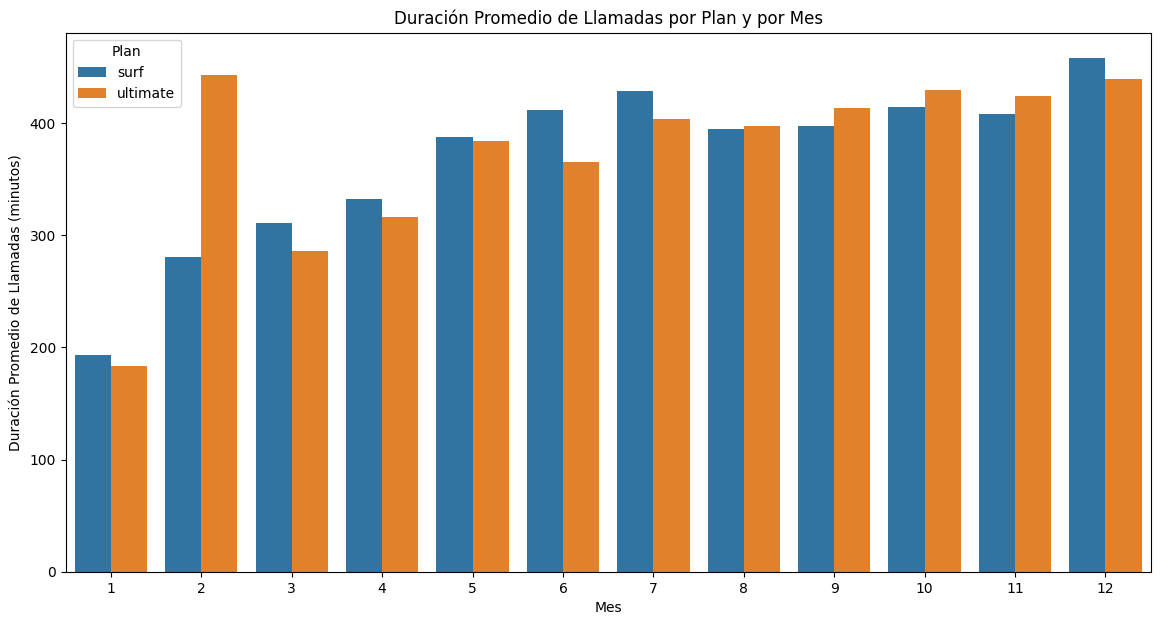

In [224]:
plan_call_duration= totals.groupby(['plan_name', 'month'])['minutes_per_month'].mean().reset_index()
plan_call_duration.rename(columns={'minutes_per_month': 'avg_call_duration'}, inplace=True)# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
print(plan_call_duration)

plt.figure(figsize=(14, 7))
sns.barplot(data=plan_call_duration, x='month', y='avg_call_duration', hue='plan_name')


plt.title('Duración Promedio de Llamadas por Plan y por Mes')
plt.xlabel('Mes')
plt.ylabel('Duración Promedio de Llamadas (minutos)')


plt.legend(title='Plan')
plt.show()




<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Muy bien! La gráfica de barras es correcta y muestra el consumo para cada uno de los planes, tiene varios puntos positivos: tiene título, nombres en los ejes y las columnas son de diferentes colores.
</div>

      user_id  month  calls_per_month   mb_used  minutes_per_month  \
1        1001      8             27.0   6919.15             171.14   
2        1001      9             49.0  13314.82             297.69   
3        1001     10             65.0  22330.49             374.11   
4        1001     11             64.0  18504.30             404.59   
5        1001     12             56.0  19369.18             392.93   
...       ...    ...              ...       ...                ...   
2288     1498     12             39.0  23137.69             324.77   
2289     1499      9             41.0  12984.76             330.37   
2290     1499     10             53.0  19492.43             363.28   
2291     1499     11             45.0  16813.83             288.56   
2292     1499     12             65.0  22059.21             468.10   

      messages_per_month  plan  messages_included  mb_per_month_included  \
1                   30.0  surf                 50                  15360   
2      

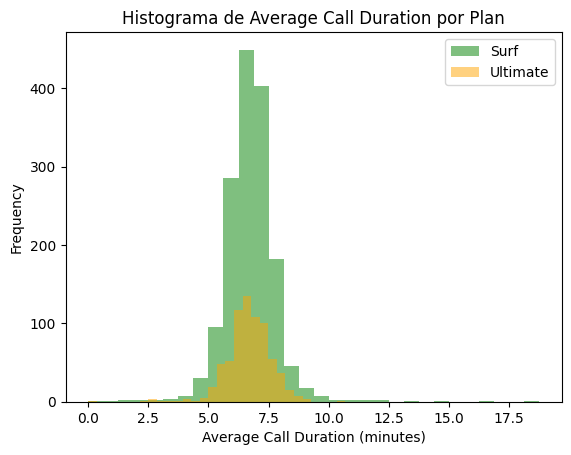

In [225]:
surf_plan_calls = totals[totals['plan_name'] == 'surf']
ultimate_plan_calls = totals[totals['plan_name'] == 'ultimate'] 

print(surf_plan_calls)
print(ultimate_plan_calls)
plt.hist(surf_plan_calls['avg_call_duration'], bins=30, alpha=0.5, label='Surf', color='green')

plt.hist(ultimate_plan_calls['avg_call_duration'], bins=30, alpha=0.5, label='Ultimate', color='orange')

plt.title('Histograma de Average Call Duration por Plan')
plt.xlabel('Average Call Duration (minutes)')
plt.ylabel('Frequency')

plt.legend()

plt.show()
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.




<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

En este histograma se debe mostrar los datos previo a ser agregados, es decir, se debe usar la tabla de totals, en lugar de plan_call_duration. De esta forma se podrá visualizar mejor el comportamiento de ambos planes, pues se podra visualizar la distribución de todos los datos, en lugar de solo los 12 meses agregados.
 
Para esto basta con realizar el siguiente cambio en las primeras líneas de tu código
    
```
surf_plan_calls = totals[totals['plan_name'] == 'surf']
ultimate_plan_calls = totals[totals['plan_name'] == 'ultimate']     
```
</div>

In [226]:
mean_duration=totals['minutes_per_month'].mean()
var_duration= np.var(totals['minutes_per_month'])
print('mean duration:', mean_duration)
print('var_duration:', var_duration)
# Calcula la media y la varianza de la duración mensual de llamadas.



mean duration: 411.4925863596103
var_duration: 48067.00576337274


<Figure size 1000x600 with 0 Axes>

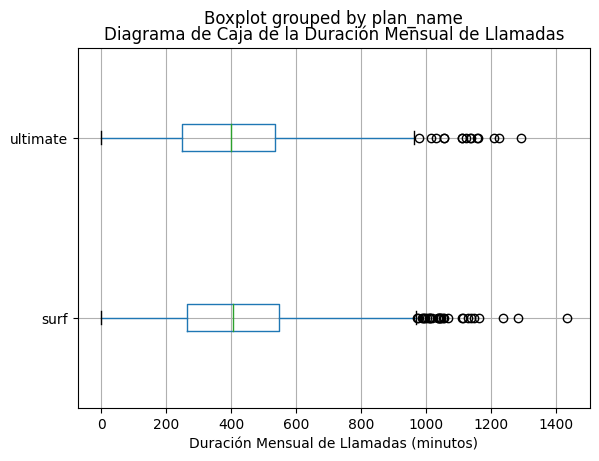

In [227]:
plt.figure(figsize=(10, 6))
totals.boxplot(column='minutes_per_month', by='plan_name', vert=False)

plt.title('Diagrama de Caja de la Duración Mensual de Llamadas')
plt.xlabel('Duración Mensual de Llamadas (minutos)')
plt.show()# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas



<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Muy bien! Estos boxplots son correctos, muestran la comparación de ambas distribuciones sobre el mismo eje. Como consejo, recomiendo usar la librería seaborn para realizar los boxplot, es más sencilla la sintaxis y ls gráficas son más bonitas, incluyen color para la comparación.
    
```
sns.boxplot(data=total, x='minutes_per_month', y='plan')    
```
</div>

<AxesSubplot:xlabel='minutes_per_month', ylabel='plan'>

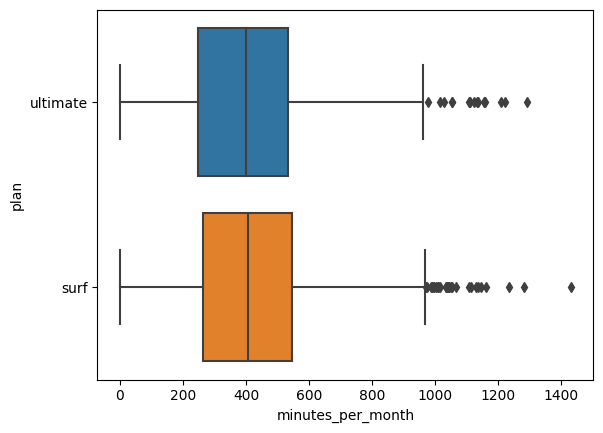

In [228]:
## código de revisor
sns.boxplot(data=totals, x='minutes_per_month', y='plan')   

Podemos ver que en promedio de la duracion de llamadas por lo general los dos planes se comportan bastante similiares en 7/12 meses las llamadas del plan surf son mas largas en promedio.

### Mensajes

   plan_name  month  avg_messages_sent
0       surf      1          21.000000
1       surf      2          21.600000
2       surf      3          21.937500
3       surf      4          24.166667
4       surf      5          33.017857
5       surf      6          33.616438
6       surf      7          35.945055
7       surf      8          37.596774
8       surf      9          39.523179
9       surf     10          42.433862
10      surf     11          40.553097
11      surf     12          48.326772
12  ultimate      1          20.666667
13  ultimate      2          25.166667
14  ultimate      3          34.714286
15  ultimate      4          28.937500
16  ultimate      5          44.333333
17  ultimate      6          36.289474
18  ultimate      7          41.212766
19  ultimate      8          47.929825
20  ultimate      9          45.901408
21  ultimate     10          46.977528
22  ultimate     11          47.601942
23  ultimate     12          53.936508


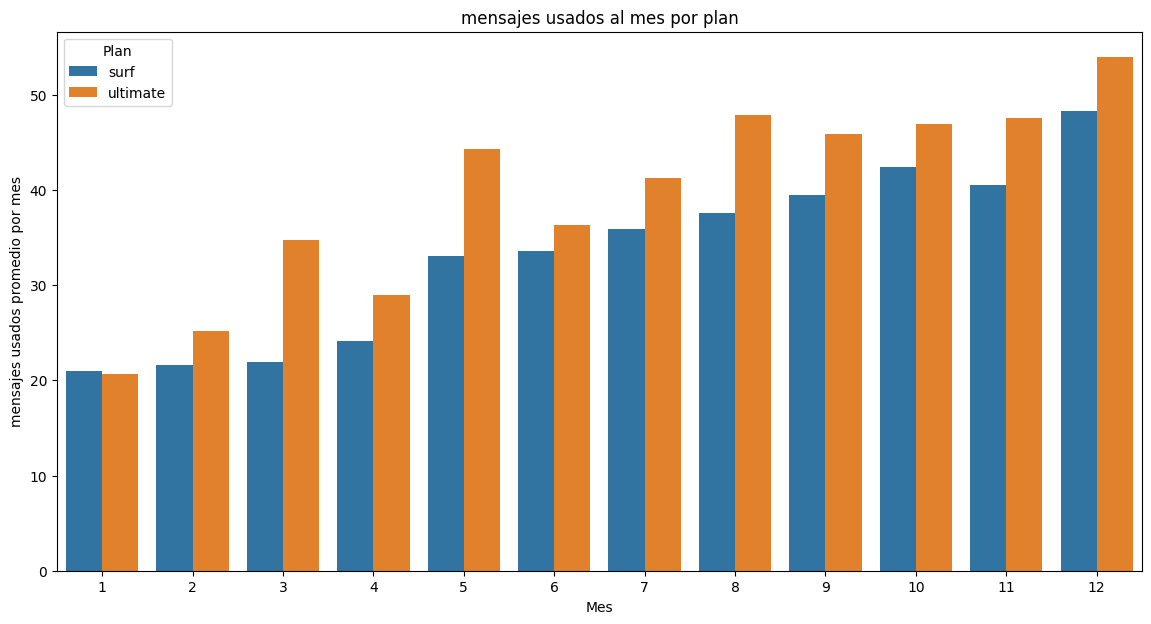

In [229]:
monthly_messages_needed= totals.groupby(['plan_name', 'month'])['messages_per_month'].mean().reset_index()
monthly_messages_needed.rename(columns={'messages_per_month': 'avg_messages_sent'}, inplace=True)# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
print(monthly_messages_needed)

plt.figure(figsize=(14, 7))
sns.barplot(data=monthly_messages_needed, x='month', y='avg_messages_sent', hue='plan_name')


plt.title('mensajes usados al mes por plan')
plt.xlabel('Mes')
plt.ylabel('mensajes usados promedio por mes')


plt.legend(title='Plan')
plt.show()


# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan



   plan_name  month  avg_messages_sent
0       surf      1          21.000000
1       surf      2          21.600000
2       surf      3          21.937500
3       surf      4          24.166667
4       surf      5          33.017857
5       surf      6          33.616438
6       surf      7          35.945055
7       surf      8          37.596774
8       surf      9          39.523179
9       surf     10          42.433862
10      surf     11          40.553097
11      surf     12          48.326772
   plan_name  month  avg_messages_sent
12  ultimate      1          20.666667
13  ultimate      2          25.166667
14  ultimate      3          34.714286
15  ultimate      4          28.937500
16  ultimate      5          44.333333
17  ultimate      6          36.289474
18  ultimate      7          41.212766
19  ultimate      8          47.929825
20  ultimate      9          45.901408
21  ultimate     10          46.977528
22  ultimate     11          47.601942
23  ultimate     12      

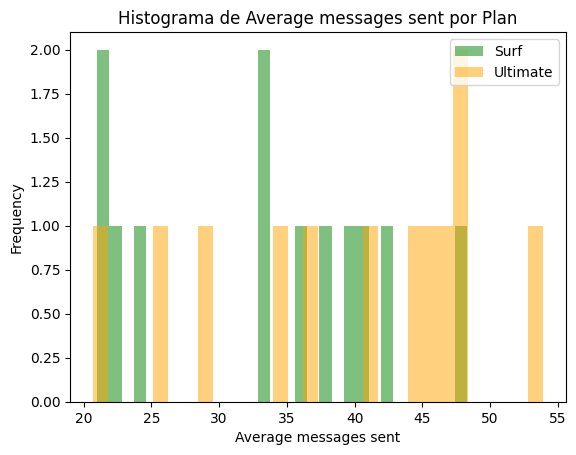

In [230]:
surf_plan_messages = monthly_messages_needed[monthly_messages_needed['plan_name'] == 'surf']
ultimate_plan_messages = monthly_messages_needed[monthly_messages_needed['plan_name'] == 'ultimate'] 

print(surf_plan_messages)
print(ultimate_plan_messages)
plt.hist(surf_plan_messages['avg_messages_sent'], bins=30, alpha=0.5, label='Surf', color='green')

plt.hist(ultimate_plan_messages['avg_messages_sent'], bins=30, alpha=0.5, label='Ultimate', color='orange')

plt.title('Histograma de Average messages sent por Plan')
plt.xlabel('Average messages sent')
plt.ylabel('Frequency')

plt.legend()

plt.show()# Compara la cantidad de tráfico de Internet consumido por usuarios por plan



In [231]:
mean_messages=totals['messages_per_month'].mean()
var_messages= np.var(totals['messages_per_month'])
print('mean messages:', mean_messages)
print('var messages:', var_messages)

mean messages: 42.110188261351055
var messages: 1096.5210811384227


<Figure size 1000x600 with 0 Axes>

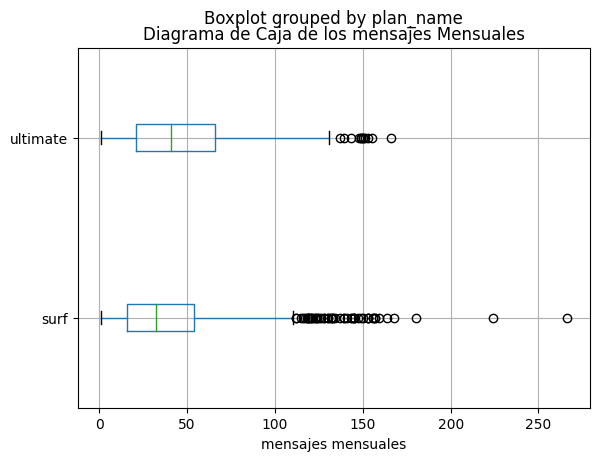

In [232]:
plt.figure(figsize=(10, 6))
totals.boxplot(column='messages_per_month', by='plan_name', vert=False)

plt.title('Diagrama de Caja de los mensajes Mensuales')
plt.xlabel('mensajes mensuales')
plt.show()

En cuanto a los mensajes si podemos notar una gran diferencia entre los usuarios de Surf y Ultimate ya que los usuarios de ultimate mandan en promedio mas mensajes al mes que los usuarios de surf

### Internet

   plan_name  month  mb_needed_monthly
0       surf      1        4874.860000
1       surf      2       12178.843333
2       surf      3       13345.440000
3       surf      4       12228.778571
4       surf      5       14119.728026
5       surf      6       15623.666632
6       surf      7       16923.463917
7       surf      8       17112.224403
8       surf      9       16677.397254
9       surf     10       17533.275256
10      surf     11       16455.548043
11      surf     12       18189.669590
12  ultimate      1        6918.092500
13  ultimate      2       17128.808571
14  ultimate      3       18321.518333
15  ultimate      4       16121.654762
16  ultimate      5       16624.482414
17  ultimate      6       15337.921064
18  ultimate      7       16344.744407
19  ultimate      8       17814.720141
20  ultimate      9       16969.869535
21  ultimate     10       17780.292000
22  ultimate     11       17033.685354
23  ultimate     12       18323.191854


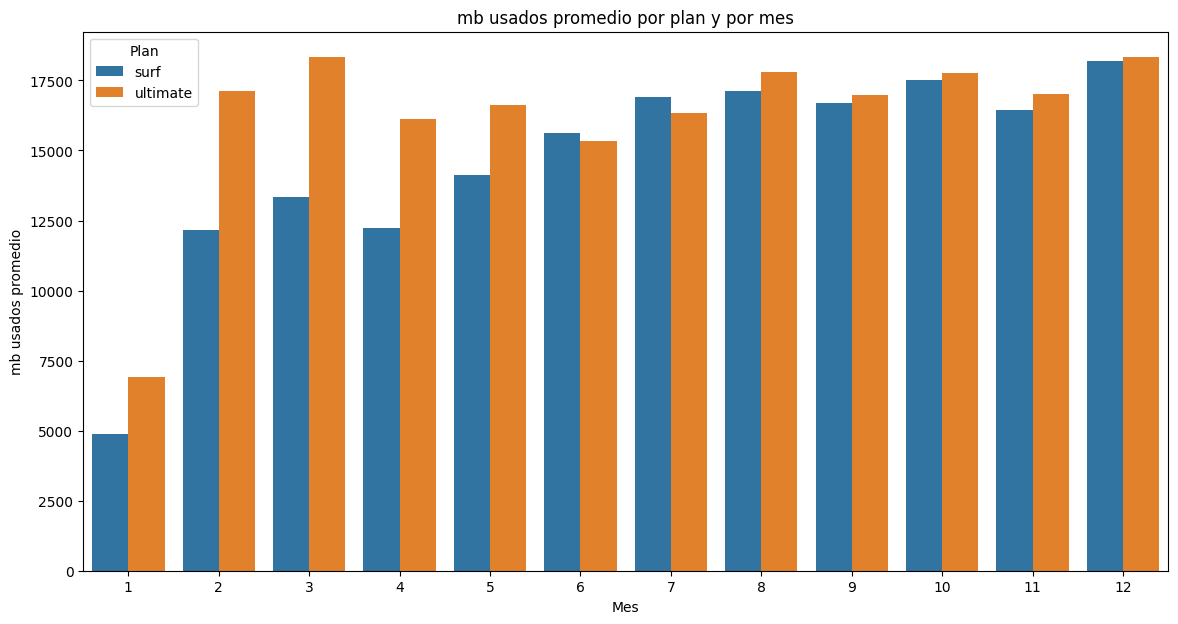

In [233]:
mb_needed= totals.groupby(['plan_name', 'month'])['mb_used'].mean().reset_index()
mb_needed.rename(columns={'mb_used': 'mb_needed_monthly'}, inplace=True)# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
print(mb_needed)

plt.figure(figsize=(14, 7))
sns.barplot(data=mb_needed, x='month', y='mb_needed_monthly', hue='plan_name')


plt.title('mb usados promedio por plan y por mes')
plt.xlabel('Mes')
plt.ylabel('mb usados promedio')


plt.legend(title='Plan')
plt.show()


   plan_name  month  mb_needed_monthly
0       surf      1        4874.860000
1       surf      2       12178.843333
2       surf      3       13345.440000
3       surf      4       12228.778571
4       surf      5       14119.728026
5       surf      6       15623.666632
6       surf      7       16923.463917
7       surf      8       17112.224403
8       surf      9       16677.397254
9       surf     10       17533.275256
10      surf     11       16455.548043
11      surf     12       18189.669590
   plan_name  month  mb_needed_monthly
12  ultimate      1        6918.092500
13  ultimate      2       17128.808571
14  ultimate      3       18321.518333
15  ultimate      4       16121.654762
16  ultimate      5       16624.482414
17  ultimate      6       15337.921064
18  ultimate      7       16344.744407
19  ultimate      8       17814.720141
20  ultimate      9       16969.869535
21  ultimate     10       17780.292000
22  ultimate     11       17033.685354
23  ultimate     12      

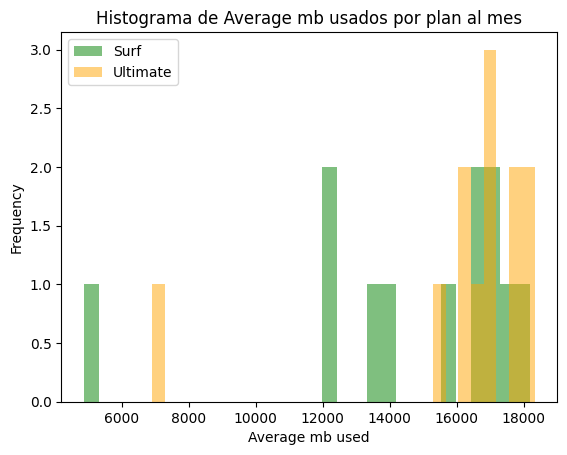

In [234]:
surf_plan_mb = mb_needed[mb_needed['plan_name'] == 'surf']
ultimate_plan_mb = mb_needed[mb_needed['plan_name'] == 'ultimate'] 
print(surf_plan_mb)
print(ultimate_plan_mb)
plt.hist(surf_plan_mb['mb_needed_monthly'], bins=30, alpha=0.5, label='Surf', color='green')

plt.hist(ultimate_plan_mb['mb_needed_monthly'], bins=30, alpha=0.5, label='Ultimate', color='orange')

plt.title('Histograma de Average mb usados por plan al mes')
plt.xlabel('Average mb used')
plt.ylabel('Frequency')

plt.legend()

plt.show()


In [235]:
mean_mb=totals['mb_used'].mean()
var_mb= np.var(totals['mb_used'])
print('mean mb:', mean_mb)
print('var mb:', var_mb)

mean mb: 16882.197501097937
var mb: 61906313.93878115


<Figure size 1000x600 with 0 Axes>

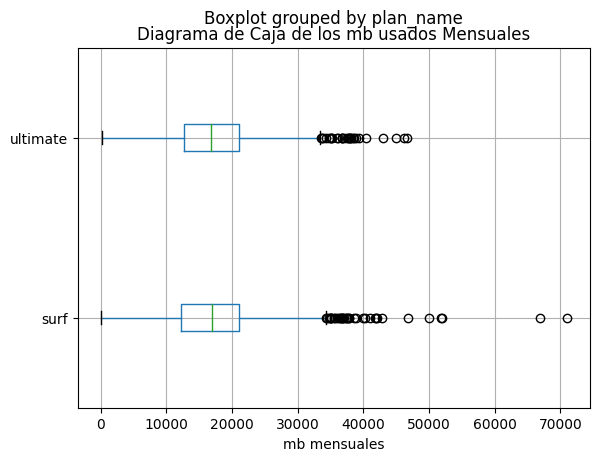

In [236]:
plt.figure(figsize=(10, 6))
totals.boxplot(column='mb_used', by='plan_name', vert=False)

plt.title('Diagrama de Caja de los mb usados Mensuales')
plt.xlabel('mb mensuales')
plt.show()

Al igual que con los mensajes podemos notar que los usuarios de Ultimate en promedio utilizan mas datos que los de Surf ya que en 9/12 meses tuvieron mas alto el uso de datos y en 5 de esos 9 meses la diferencia fue considerable.

## Ingreso

   plan_name  month  monthly_revenue
0       surf      1        20.000000
1       surf      2        23.662120
2       surf      3        38.323500
3       surf      4        40.262346
4       surf      5        50.364445
5       surf      6        51.750469
6       surf      7        61.354021
7       surf      8        64.015463
8       surf      9        56.854326
9       surf     10        64.978578
10      surf     11        56.716289
11      surf     12        68.283588
12  ultimate      1        70.000000
13  ultimate      2        70.000000
14  ultimate      3        78.000000
15  ultimate      4        73.062500
16  ultimate      5        71.000000
17  ultimate      6        72.081081
18  ultimate      7        72.382979
19  ultimate      8        72.456140
20  ultimate      9        71.380282
21  ultimate     10        72.147727
22  ultimate     11        72.127451
23  ultimate     12        72.744000


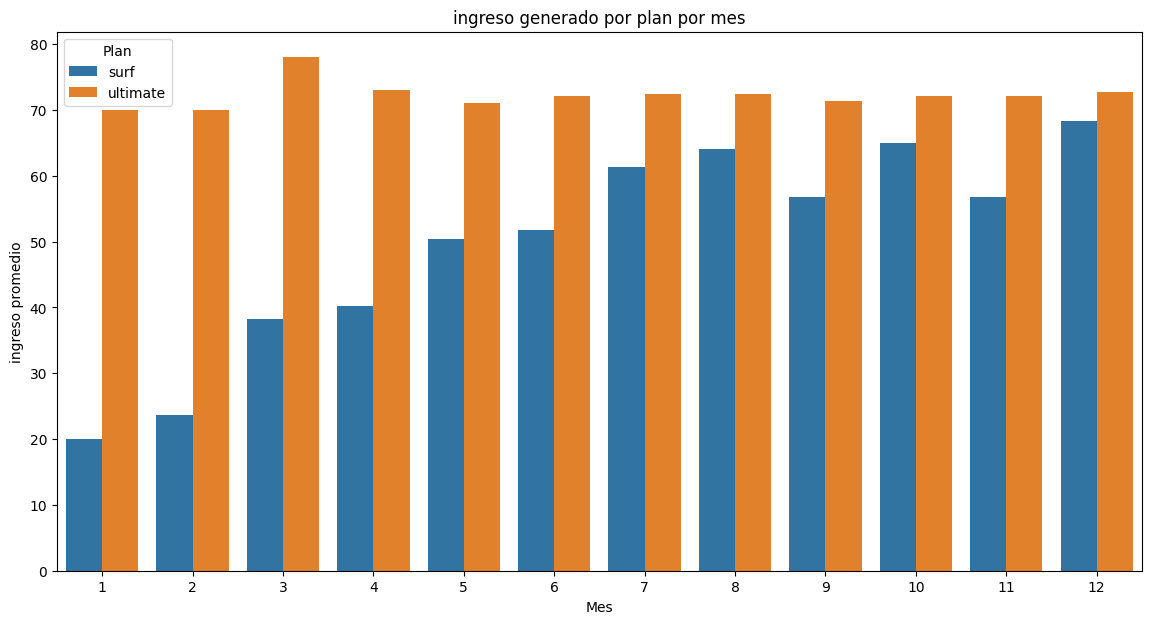

In [237]:
income_generated= totals.groupby(['plan_name', 'month'])['monthly_revenue'].mean().reset_index()
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
print(income_generated)

plt.figure(figsize=(14, 7))
sns.barplot(data=income_generated, x='month', y='monthly_revenue', hue='plan_name')


plt.title('ingreso generado por plan por mes')
plt.xlabel('Mes')
plt.ylabel('ingreso promedio')


plt.legend(title='Plan')
plt.show()


   plan_name  month  monthly_revenue
0       surf      1        20.000000
1       surf      2        23.662120
2       surf      3        38.323500
3       surf      4        40.262346
4       surf      5        50.364445
5       surf      6        51.750469
6       surf      7        61.354021
7       surf      8        64.015463
8       surf      9        56.854326
9       surf     10        64.978578
10      surf     11        56.716289
11      surf     12        68.283588
   plan_name  month  monthly_revenue
12  ultimate      1        70.000000
13  ultimate      2        70.000000
14  ultimate      3        78.000000
15  ultimate      4        73.062500
16  ultimate      5        71.000000
17  ultimate      6        72.081081
18  ultimate      7        72.382979
19  ultimate      8        72.456140
20  ultimate      9        71.380282
21  ultimate     10        72.147727
22  ultimate     11        72.127451
23  ultimate     12        72.744000


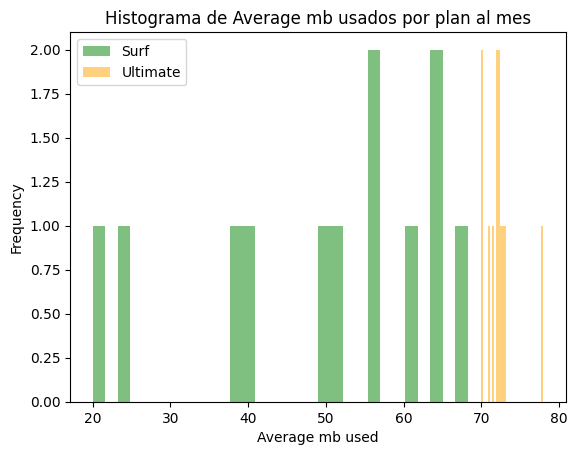

In [238]:
surf_income = income_generated[income_generated['plan_name'] == 'surf']
ultimate_income = income_generated[income_generated['plan_name'] == 'ultimate'] 
print(surf_income)
print(ultimate_income)
plt.hist(surf_income['monthly_revenue'], bins=30, alpha=0.5, label='Surf', color='green')

plt.hist(ultimate_income['monthly_revenue'], bins=30, alpha=0.5, label='Ultimate', color='orange')

plt.title('Histograma de Average mb usados por plan al mes')
plt.xlabel('Average mb used')
plt.ylabel('Frequency')

plt.legend()

plt.show()


In [239]:
mean_income=totals['monthly_revenue'].mean()
var_income= np.var(totals['monthly_revenue'])
print('mean income:', mean_income)
print('var income:', var_income)

mean income: 64.0383667424673
var income: 1987.2183912127712


<Figure size 1000x600 with 0 Axes>

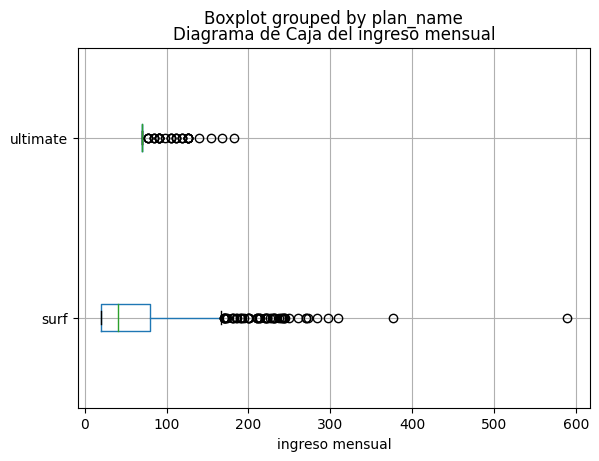

In [240]:
plt.figure(figsize=(10, 6))
totals.boxplot(column='monthly_revenue', by='plan_name', vert=False)

plt.title('Diagrama de Caja del ingreso mensual')
plt.xlabel('ingreso mensual')
plt.show()

Podemos observar una diferencia considerable en la contribucion al ingreso por cada plan, en los 12 meses podemos observar que los usuarios del plan Ultimate contribuyen mas ya que inicialmente el plan es de 70 mas aparte los costos extras ya que este se utiliza mas aunque en realidad la diferencia en el costo es mucho mas alta de la diferencia en lo mucho que lo usan los usuarios. Por lo que considero que cambiarse al plan surf podria ser conveniente para algunos usuarios del plan ultimate.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen trabajo. Realizaste las gráficas solicitadas para intenernet, mensajes e ingreso. Solo falta corregir el histograma tomando los datos de la tabla totals, para estas variables aplica lo mismo que para llamadas pero cambiando la columna correspondiente.
</div>

## Prueba las hipótesis estadísticas

In [241]:
print('hipotesis nula: Los ingresos promedio de los usuarios de los planes de llamada Ultimate y Surf son iguales.')
print('hipotesis alternativa:los ingresos promedio de los usuarios de los planes de llamada Ultimate y Surf son diferentes ')

hipotesis nula: Los ingresos promedio de los usuarios de los planes de llamada Ultimate y Surf son iguales.
hipotesis alternativa:los ingresos promedio de los usuarios de los planes de llamada Ultimate y Surf son diferentes 


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, recuerda describir la hipótesis nula y alternativa previo a realizar los cáculos.
</div>

In [242]:
print(ultimate_income.dropna())
print(surf_income.dropna())

   plan_name  month  monthly_revenue
12  ultimate      1        70.000000
13  ultimate      2        70.000000
14  ultimate      3        78.000000
15  ultimate      4        73.062500
16  ultimate      5        71.000000
17  ultimate      6        72.081081
18  ultimate      7        72.382979
19  ultimate      8        72.456140
20  ultimate      9        71.380282
21  ultimate     10        72.147727
22  ultimate     11        72.127451
23  ultimate     12        72.744000
   plan_name  month  monthly_revenue
0       surf      1        20.000000
1       surf      2        23.662120
2       surf      3        38.323500
3       surf      4        40.262346
4       surf      5        50.364445
5       surf      6        51.750469
6       surf      7        61.354021
7       surf      8        64.015463
8       surf      9        56.854326
9       surf     10        64.978578
10      surf     11        56.716289
11      surf     12        68.283588


In [243]:
ultimate_revenue = totals[totals['plan_name'] == 'ultimate']['monthly_revenue']
surf_revenue = totals[totals['plan_name'] == 'surf']['monthly_revenue']
ultimate_revenue= ultimate_revenue.dropna()
surf_revenue= surf_revenue.dropna()

alpha=.05
results = st.ttest_ind(ultimate_revenue, surf_revenue, equal_var=False)# Prueba las hipótesis

print('valor p:', results.pvalue)
if (results.pvalue<alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 8.125171576846435e-14
Rechazamos la hipótesis nula


In [244]:
print('El ingreso promedio de los usuarios en el área NY-NJ es igual al ingreso promedio de los usuarios en otras regiones.')
print('El ingreso promedio de los usuarios en el área NY-NJ es diferente del ingreso promedio de los usuarios en otras regiones.')

El ingreso promedio de los usuarios en el área NY-NJ es igual al ingreso promedio de los usuarios en otras regiones.
El ingreso promedio de los usuarios en el área NY-NJ es diferente del ingreso promedio de los usuarios en otras regiones.


In [245]:
totalscity = totals.merge(megaline_users[['user_id', 'city']], on='user_id', how='left').reset_index()
totalscity.head()

,index,user_id,month,calls_per_month,mb_used,minutes_per_month,messages_per_month,plan,messages_included,mb_per_month_included,...,plan_name,extra_minutes,extra_messages,extra_mb,cost_extra_minutes,cost_extra_messages,cost_extra_gb,monthly_revenue,avg_call_duration,city
0,0,1000,12,16.0,1901.47,116.83,11.0,ultimate,1000,30720,...,ultimate,0.0,0.0,0.00,0.0,0.00,0.0,70.00,7.301875,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1,1001,8,27.0,6919.15,171.14,30.0,surf,50,15360,...,surf,0.0,0.0,0.00,0.0,0.00,0.0,20.00,6.338519,"Seattle-Tacoma-Bellevue, WA MSA"
2,2,1001,9,49.0,13314.82,297.69,44.0,surf,50,15360,...,surf,0.0,0.0,0.00,0.0,0.00,0.0,20.00,6.075306,"Seattle-Tacoma-Bellevue, WA MSA"
3,3,1001,10,65.0,22330.49,374.11,53.0,surf,50,15360,...,surf,0.0,3.0,6970.49,0.0,0.09,70.0,90.09,5.755538,"Seattle-Tacoma-Bellevue, WA MSA"
4,4,1001,11,64.0,18504.30,404.59,36.0,surf,50,15360,...,surf,0.0,0.0,3144.30,0.0,0.00,40.0,60.00,6.321719,"Seattle-Tacoma-Bellevue, WA MSA"


In [246]:
ny_nj_revenue = totalscity[totalscity['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_revenue'].dropna()
other_regions_revenue = totalscity[totalscity['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_revenue'].dropna()

# Definir el nivel de significancia
alpha = 0.05

# Realizar la prueba t de muestras independientes
results = st.ttest_ind(ny_nj_revenue, other_regions_revenue, equal_var=False)

# Mostrar el valor p
print('Valor p:', results.pvalue)

# Decisión
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula.")
else:
    print("No podemos rechazar la hipótesis nula.")# Prueba las hipótesis



Valor p: 0.004024256220178592
Rechazamos la hipótesis nula.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen trabajo. ¡Lo hiciste muy bien!
</div>

In [247]:
print('el ingreso promedio es diferente entre NY-NJ y otras regiones')

el ingreso promedio es diferente entre NY-NJ y otras regiones


## Conclusión general



Este proyecto fue mas dificil para mi ya que volvi de una pausa del bootcamp y no recordaba bien todo lo estudiado anteriormente, considero que es un buen proyecto y en mis decisiones al momento de limpiar datos y concatenar dataframes para poder realizar histogramas y graficos de barras voy recordando lo estudiado y con ayuda poder mejorar en la ciencia de datos.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Hola!
    
Te quiero felicitar por tu dedicación y esfuerzo, se notan en la realización de este proyecto. Solo quedan un par de detalles a corregir para que se encuentre completo, estos cambios los mencioné en bloques de color rojo, en cuanto los termines podré aprobar tu trabajo. También realicé comentarios opcionales en bloques de color amarillo. 
    
Sé que podrás realizar los cambios necesarios con éxito.
    
Saludos, Marcos.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Muy bien, gracias por atender a los comentarios.
</div>